# 02. Model Evaluation

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import get_config

CONFIG = get_config()

In [2]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from src.model import FER2013CNN
from src.data import FER2013Dataset, val_test_transform, get_dataloader

In [3]:
test_dataset = FER2013Dataset(
    split=CONFIG["data"]["test_split"],
    transform=val_test_transform
)
test_loader = get_dataloader(test_dataset)

checkpoint_cfg = CONFIG["callbacks"]["checkpoint"]
checkpoint_root = PROJECT_ROOT / checkpoint_cfg["root_dir"]
run_prefix = checkpoint_cfg["run_prefix"]
best_filename = checkpoint_cfg["best_filename"]

run_dirs = sorted(
    [path for path in checkpoint_root.glob(f"{run_prefix}*") if path.is_dir()]
)

if run_dirs:
    checkpoint_path = run_dirs[-1] / best_filename
else:
    checkpoint_path = checkpoint_root / best_filename

if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

print(f"Using checkpoint: {checkpoint_path}")

Using checkpoint: /home/miguel/git/fer-2013/checkpoints/checkpoint_20260226140935/best_model.pt


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FER2013CNN(input_channels=test_dataset.input_channels)
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

FER2013CNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(9, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d

In [5]:
ground_truths = []
predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predicted = outputs.argmax(dim=1)

        ground_truths.extend(labels.cpu().tolist())
        predictions.extend(predicted.cpu().tolist())

In [6]:
idx_to_class = {idx: cls for cls, idx in test_dataset.class_to_idx.items()}
class_names = [idx_to_class[idx] for idx in sorted(idx_to_class)]

print(
    classification_report(
        ground_truths,
        predictions,
        target_names=class_names,
        digits=4,
    )
)

              precision    recall  f1-score   support

       angry     0.5713    0.5939    0.5824       958
     disgust     0.6789    0.6667    0.6727       111
        fear     0.5000    0.3730    0.4273      1024
       happy     0.8692    0.8388    0.8537      1774
     neutral     0.5733    0.7105    0.6346      1233
         sad     0.5384    0.4667    0.5000      1247
    surprise     0.7034    0.8363    0.7642       831

    accuracy                         0.6500      7178
   macro avg     0.6335    0.6409    0.6335      7178
weighted avg     0.6463    0.6500    0.6444      7178



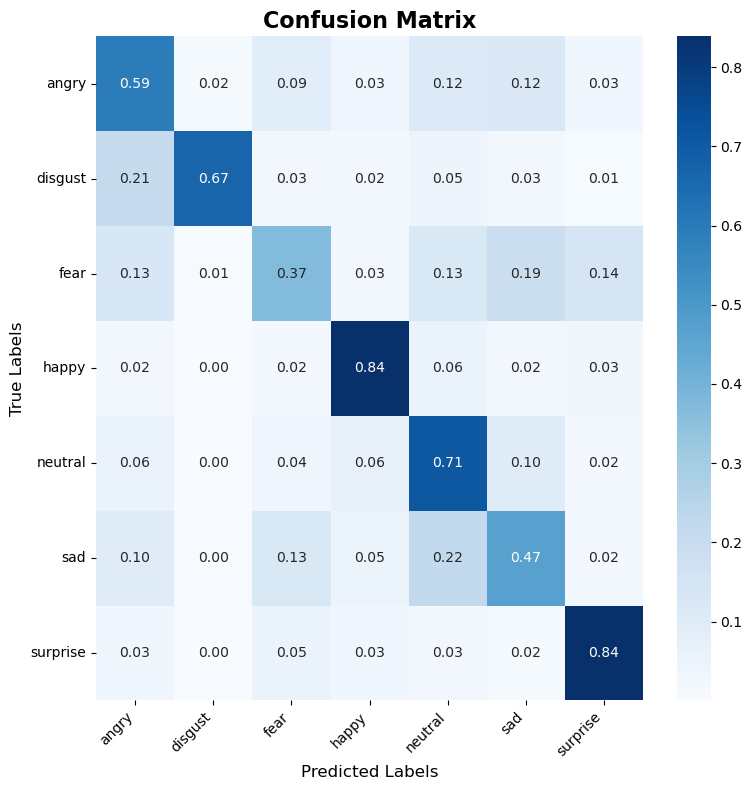

In [16]:
cm = confusion_matrix(ground_truths, predictions, normalize='true')

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
 )

ax.set_title("Confusion Matrix", fontsize=16, fontweight="bold")
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{Path(run_dirs[-1] / "confusion_matrix.png")}', dpi=300)
plt.show()

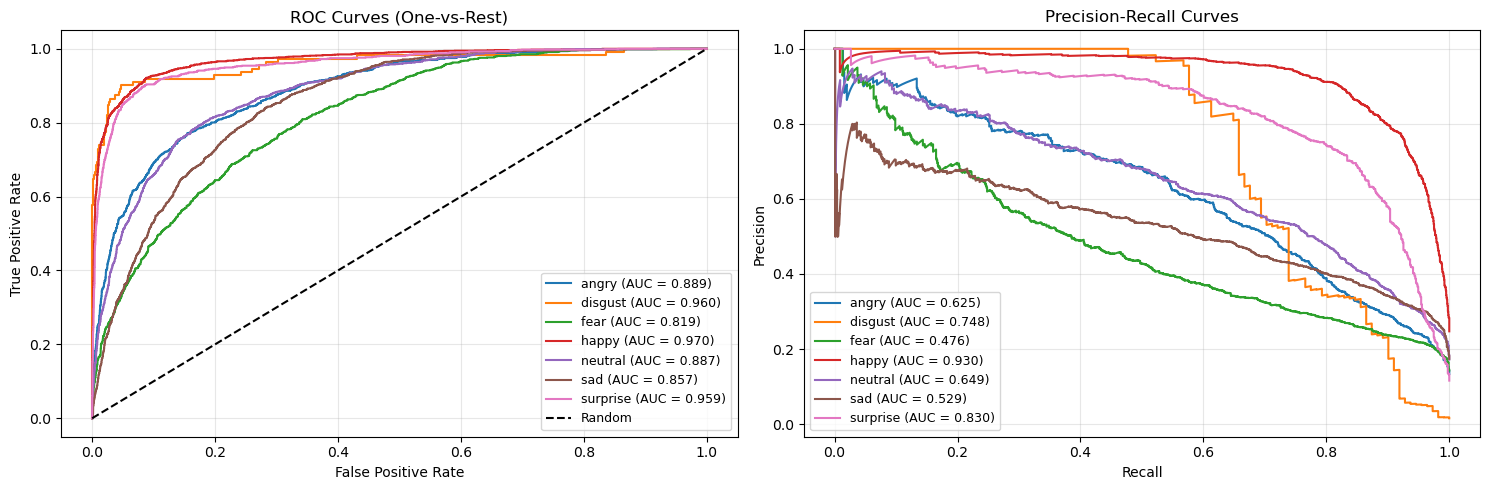

In [17]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np

# Get probabilities for all predictions
all_probs = []
ground_truths_roc = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        ground_truths_roc.extend(labels.cpu().tolist())

all_probs = np.array(all_probs)
ground_truths_roc = np.array(ground_truths_roc)

# Binarize ground truth for multi-class
gt_binarized = label_binarize(ground_truths_roc, classes=range(len(class_names)))

# Compute ROC curve and PR curve for each class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC Curves
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(gt_binarized[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (One-vs-Rest)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# PR Curves
for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(gt_binarized[:, i], all_probs[:, i])
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, label=f'{class_name} (AUC = {pr_auc:.3f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{run_dirs[-1]}/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()